# Import Modules

In [34]:
import numpy as np
import pandas as pd 
import xgboost as xgb
from sklearn.metrics import accuracy_score
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix

# Import Data

In [20]:
def choose_header(n, location, lead_time):
    """
    Generate header names for n closest storms.

    Returns:
        tuple of two lists:
            - input headers: year, month, day, hour, minute, lat1..n, lon1..n, wp1..n, size1..n, d1..n, mask1..n
            - target header: Cb_{location}_t{lead_time}
    """
    input_headers = ['year', 'month', 'day', 'hour', 'minute']
    
    for prefix in ['lat', 'lon', 'wp', 'size', 'd', 'mask']:
        input_headers.extend([f'{prefix}{i}' for i in range(1, n + 1)])
    
    target_header = [f'Cb_{location}_t{lead_time}']
    
    return input_headers, target_header

In [10]:
train = pd.read_csv("../../../output/data/dakar/data-train-eps-dakar.csv")
test = pd.read_csv("../../../output/data/dakar/data-test-eps-dakar.csv")

# Choose lead time

In [ ]:
lead_time = 1

In [ ]:
input_headers, target_header = choose_header(3, "dakar", lead_time)

In [28]:
X_train = train[input_headers]
X_test = test[input_headers]

y_train = train[target_header]
y_test = test[target_header]
y_persistence = test["Cb_dakar_t0"]

In [41]:
n_neg = y_train.value_counts()[0]
n_pos = y_train.value_counts()[1]

# Exploratory data analysis

<Axes: xlabel='Cb_dakar_t1'>

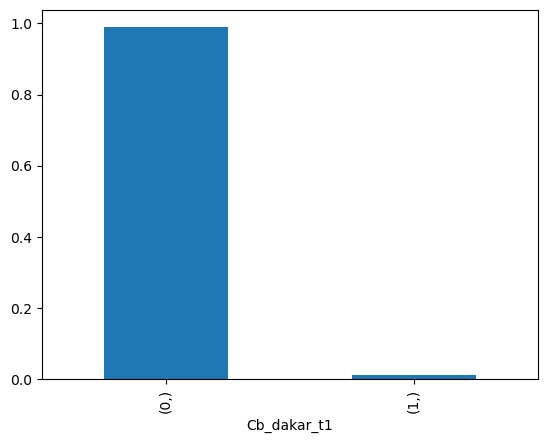

In [44]:
y_train.value_counts(normalize=True).plot(kind='bar')

In [ ]:
real_mask = (df['mask1'] == 1) | (df['mask2'] == 1) | (df['mask3'] == 1)

for feature in ['wp1', 'size1', 'd1']:
    sns.histplot(data=df[real_mask], x=feature, hue='Cb_dakar_t1', kde=True, common_norm=False)
    plt.title(f'{feature} distribution by target')
    plt.show()
